In [ ]:
# install libraries

%pip install pandas
%pip install scikit-learn
%pip install numpy
%pip install torch
%pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.8 MB/s eta 0:00:00


Mounted at /content/drive
Loaded Successfully

patients: (10200, 4)
admissions: (25059, 7)
icu: (25059, 4)
diagnoses: (74810, 4)
procedures: (62542, 2)
medications: (100576, 3)
labs: (363744, 3)
comorbidities: (19961, 2)
outcomes: (25059, 7)

CLEANING
Cleaning Complete

Master Shape
(25059, 17)

Master Shape After Merge
(25059, 30)

HOSPITAL KPIs
Average LOS
10.002793407558162

Median LOS
10.0

Readmission Rate
0.14860928209425756

Hospital Mortality
0.09964483818189074

ICU LOS
3.9917115607167086

BOTTLENECKS

Longest LOS
admission_type
OBSERVATION    10.067832
URGENT         10.059581
ELECTIVE        9.993051
EMERGENCY       9.891896
Name: los_days, dtype: float64

Highest Resource Use
admission_type
OBSERVATION    20.428801
EMERGENCY      20.427002
URGENT         20.331240
ELECTIVE       20.275111
Name: resource_score, dtype: float64


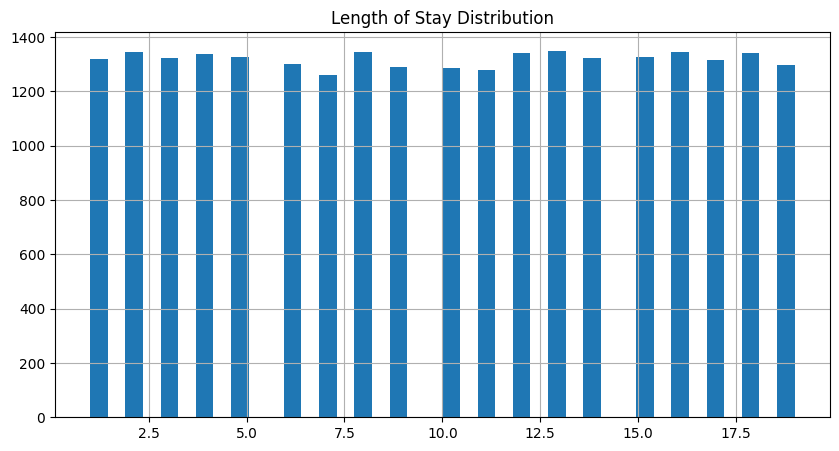

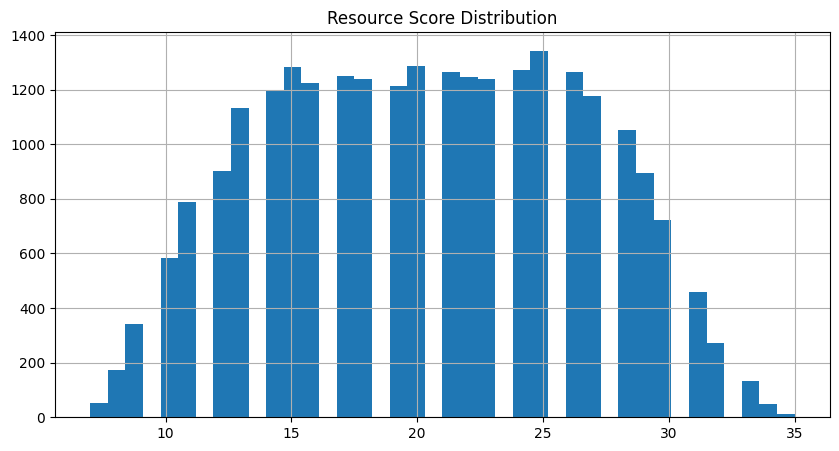


OUTCOMES
Mortality Rate
0.08372241510036314

Sepsis Rate
0.12043577157907338

Ventilation Rate
0.08096891336445987

Top Mortality Correlations
mortality_90d            1.000000
los_days                 0.166417
long_stay                0.146039
mortality                0.029316
icu_los                  0.015797
sofa                     0.007531
sepsis                   0.005899
subject_id               0.005458
hadm_id                  0.005453
Diabetes                 0.005406
resource_score           0.005344
num_labs                 0.004988
num_medications          0.004521
anchor_age               0.004520
COPD                     0.003657
high_resource_patient    0.001204
ventilation              0.000595
readmit_30d              0.000493
CKD                     -0.000216
num_diagnoses           -0.000844
Name: mortality_90d, dtype: float64

MODEL RESULTS
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      4590
           1    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


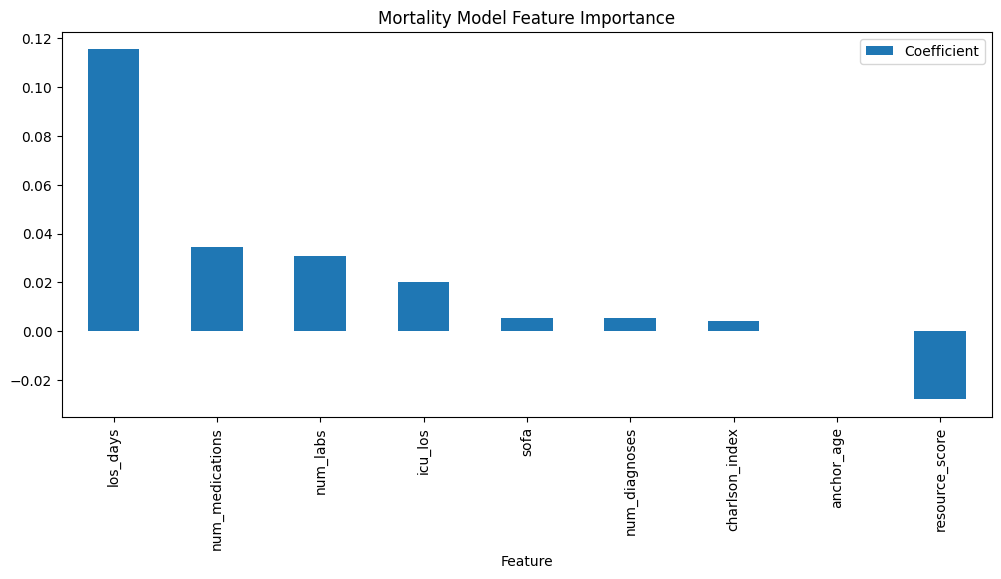

/tmp/ipykernel_2062/1892323514.py:485: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  master.groupby("age_group")



Age Group Analysis
           mortality_rate    avg_los  avg_resource
age_group                                         
18-40            0.080635   9.937475     20.398810
41-60            0.085113  10.034355     20.379759
61-80            0.086541  10.059109     20.390573
80+              0.082770   9.984438     20.249662

master_dataset.csv saved successfully

Columns
['hadm_id', 'subject_id', 'admittime', 'dischtime', 'los_days', 'admission_type', 'discharge_location', 'anchor_age', 'gender', 'race', 'icu_los', 'sofa', 'mortality', 'mortality_90d', 'readmit_30d', 'sepsis', 'ventilation', 'num_diagnoses', 'num_procedures', 'num_medications', 'num_labs', 'mean_lab', 'max_lab', 'min_lab', 'std_lab', 'CHF', 'CKD', 'COPD', 'Diabetes', 'Hypertension', 'resource_score', 'long_stay', 'high_resource_patient', 'charlson_index', 'age_group']

Preview


,hadm_id,subject_id,admittime,dischtime,los_days,admission_type,discharge_location,anchor_age,gender,race,...,CHF,CKD,COPD,Diabetes,Hypertension,resource_score,long_stay,high_resource_patient,charlson_index,age_group
0,200000,100000,2022-01-06,2022-01-23,17,URGENT,EXPIRED,69,M,ASIAN,...,0,0,1,0,0,19,1,0,3.2,61-80
1,200001,100000,2019-11-08,2019-11-20,12,ELECTIVE,HOME,69,M,ASIAN,...,0,0,1,0,0,18,1,0,3.2,61-80
2,200002,100000,2023-09-04,2023-09-23,19,ELECTIVE,REHAB,69,M,ASIAN,...,0,0,1,0,0,31,1,1,4.0,61-80
3,200003,100000,2023-06-14,2023-06-28,14,URGENT,EXPIRED,69,M,ASIAN,...,0,0,1,0,0,28,1,1,2.4,61-80
4,200004,100001,2019-08-15,2019-08-23,8,OBSERVATION,EXPIRED,32,F,HISPANIC,...,0,1,1,0,0,18,0,0,0.8,18-40



Final Shape
(25059, 35)


In [ ]:
# =====================================================
# SYNTHETIC MIMIC ANALYSIS NOTEBOOK
# NOTEBOOK 2
# =====================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# =====================================================
# SECTION 1: LOAD DATA
# =====================================================

DATA_PATH = "/content/drive/MyDrive/synthetic_mimic"

patients = pd.read_csv(f"{DATA_PATH}/patients.csv")
admissions = pd.read_csv(f"{DATA_PATH}/admissions.csv")
icu = pd.read_csv(f"{DATA_PATH}/icu_stays.csv")
diagnoses = pd.read_csv(f"{DATA_PATH}/diagnoses.csv")
procedures = pd.read_csv(f"{DATA_PATH}/procedures.csv")
medications = pd.read_csv(f"{DATA_PATH}/medications.csv")
labs = pd.read_csv(f"{DATA_PATH}/labs.csv")
comorbidities = pd.read_csv(f"{DATA_PATH}/comorbidities.csv")
outcomes = pd.read_csv(f"{DATA_PATH}/outcomes.csv")

print("Loaded Successfully\n")

for name, df in {
    "patients": patients,
    "admissions": admissions,
    "icu": icu,
    "diagnoses": diagnoses,
    "procedures": procedures,
    "medications": medications,
    "labs": labs,
    "comorbidities": comorbidities,
    "outcomes": outcomes
}.items():

    print(f"{name}: {df.shape}")

# =====================================================
# SECTION 2: CLEANING
# =====================================================

print("\n========================")
print("CLEANING")
print("========================")

patients = patients.drop_duplicates()
admissions = admissions.drop_duplicates()
icu = icu.drop_duplicates()
diagnoses = diagnoses.drop_duplicates()
procedures = procedures.drop_duplicates()
medications = medications.drop_duplicates()
labs = labs.drop_duplicates()

patients["race"] = patients["race"].fillna("UNKNOWN")

patients["gender"] = patients["gender"].replace({
    "Male":"M",
    "Female":"F"
})

labs["lab_value"] = pd.to_numeric(
    labs["lab_value"],
    errors="coerce"
)

labs["lab_value"] = labs.groupby(
    "lab_name"
)["lab_value"].transform(
    lambda x: x.fillna(x.median())
)

admissions["admittime"] = pd.to_datetime(
    admissions["admittime"]
)

admissions["dischtime"] = pd.to_datetime(
    admissions["dischtime"]
)

print("Cleaning Complete")

# =====================================================
# SECTION 3: MASTER DATASET
# =====================================================

master = admissions.merge(
    patients,
    on="subject_id",
    how="left"
)

master = master.merge(
    icu,
    on=["hadm_id","subject_id"],
    how="left"
)

master = master.merge(
    outcomes,
    on=["hadm_id","los_days"],
    how="left"
)

print("\nMaster Shape")
print(master.shape)

# =====================================================
# SECTION 4: AGGREGATIONS
# =====================================================

diag_counts = (
    diagnoses.groupby("hadm_id")
    .size()
    .reset_index(name="num_diagnoses")
)

proc_counts = (
    procedures.groupby("hadm_id")
    .size()
    .reset_index(name="num_procedures")
)

med_counts = (
    medications.groupby("hadm_id")
    .size()
    .reset_index(name="num_medications")
)

lab_counts = (
    labs.groupby("hadm_id")
    .size()
    .reset_index(name="num_labs")
)

master = master.merge(
    diag_counts,
    on="hadm_id",
    how="left"
)

master = master.merge(
    proc_counts,
    on="hadm_id",
    how="left"
)

master = master.merge(
    med_counts,
    on="hadm_id",
    how="left"
)

master = master.merge(
    lab_counts,
    on="hadm_id",
    how="left"
)

# =====================================================
# SECTION 5: LAB SUMMARY FEATURES
# =====================================================

lab_summary = (
    labs.groupby("hadm_id")
    .agg(
        mean_lab=("lab_value","mean"),
        max_lab=("lab_value","max"),
        min_lab=("lab_value","min"),
        std_lab=("lab_value","std")
    )
    .reset_index()
)

master = master.merge(
    lab_summary,
    on="hadm_id",
    how="left"
)

# =====================================================
# SECTION 6: COMORBIDITIES
# =====================================================

comorb_matrix = pd.crosstab(
    comorbidities["subject_id"],
    comorbidities["condition"]
)

comorb_matrix = comorb_matrix.reset_index()

master = master.merge(
    comorb_matrix,
    on="subject_id",
    how="left"
)

master.fillna(0, inplace=True)

print("\nMaster Shape After Merge")
print(master.shape)

# =====================================================
# SECTION 7: FEATURE ENGINEERING
# =====================================================

master["resource_score"] = (
    master["num_labs"]
    +
    master["num_medications"]
    +
    master["num_procedures"]
)

master["long_stay"] = (
    master["los_days"]
    >
    master["los_days"].median()
).astype(int)

master["high_resource_patient"] = (
    master["resource_score"]
    >
    master["resource_score"].median()
).astype(int)

master["charlson_index"] = (
    master["num_diagnoses"] * 0.8
)

master["age_group"] = pd.cut(
    master["anchor_age"],
    bins=[0,40,60,80,120],
    labels=[
        "18-40",
        "41-60",
        "61-80",
        "80+"
    ]
)

# =====================================================
# SECTION 8: HOSPITAL KPIs
# =====================================================

print("\n========================")
print("HOSPITAL KPIs")
print("========================")

print("Average LOS")
print(master["los_days"].mean())

print("\nMedian LOS")
print(master["los_days"].median())

print("\nReadmission Rate")
print(master["readmit_30d"].mean())

print("\nHospital Mortality")
print(master["mortality"].mean())

print("\nICU LOS")
print(master["icu_los"].mean())

# =====================================================
# SECTION 9: BOTTLENECKS
# =====================================================

print("\n========================")
print("BOTTLENECKS")
print("========================")

top_los = (
    master.groupby("admission_type")
    ["los_days"]
    .mean()
    .sort_values(ascending=False)
)

print("\nLongest LOS")

print(top_los)

top_resources = (
    master.groupby("admission_type")
    ["resource_score"]
    .mean()
    .sort_values(ascending=False)
)

print("\nHighest Resource Use")

print(top_resources)

# =====================================================
# SECTION 10: VISUALIZATIONS
# =====================================================

plt.figure(figsize=(10,5))

master["los_days"].hist(
    bins=40
)

plt.title(
    "Length of Stay Distribution"
)

plt.show()

plt.figure(figsize=(10,5))

master["resource_score"].hist(
    bins=40
)

plt.title(
    "Resource Score Distribution"
)

plt.show()

# =====================================================
# SECTION 11: OUTCOMES
# =====================================================

print("\n========================")
print("OUTCOMES")
print("========================")

print("Mortality Rate")

print(master["mortality_90d"].mean())

print("\nSepsis Rate")

print(master["sepsis"].mean())

print("\nVentilation Rate")

print(master["ventilation"].mean())

# =====================================================
# SECTION 12: CORRELATIONS
# =====================================================

numeric_cols = master.select_dtypes(
    include=np.number
).columns

corr = master[
    numeric_cols
].corr()

print("\nTop Mortality Correlations")

print(
    corr["mortality_90d"]
    .sort_values(
        ascending=False
    )
    .head(20)
)

# =====================================================
# SECTION 13: MORTALITY MODEL
# =====================================================

features = [
    "anchor_age",
    "charlson_index",
    "sofa",
    "num_diagnoses",
    "num_medications",
    "num_labs",
    "resource_score",
    "icu_los",
    "los_days"
]

X = master[features]

y = master["mortality_90d"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(
    max_iter=5000
)

model.fit(
    X_train,
    y_train
)

preds = model.predict(X_test)

print("\n========================")
print("MODEL RESULTS")
print("========================")

print(
    classification_report(
        y_test,
        preds
    )
)

print("\nROC AUC")

try:
    probs = model.predict_proba(
        X_test
    )[:,1]

    print(
        roc_auc_score(
            y_test,
            probs
        )
    )

except:
    pass

# =====================================================
# SECTION 14: FEATURE IMPORTANCE
# =====================================================

importance = pd.DataFrame({

    "Feature":features,

    "Coefficient":
    model.coef_[0]

})

importance = importance.sort_values(
    "Coefficient",
    ascending=False
)

print("\nFeature Importance")

print(importance)

importance.plot(
    x="Feature",
    y="Coefficient",
    kind="bar",
    figsize=(12,5)
)

plt.title(
    "Mortality Model Feature Importance"
)

plt.show()

# =====================================================
# SECTION 15: AGE GROUP ANALYSIS
# =====================================================

age_analysis = (
    master.groupby("age_group")
    .agg(
        mortality_rate=(
            "mortality_90d",
            "mean"
        ),
        avg_los=(
            "los_days",
            "mean"
        ),
        avg_resource=(
            "resource_score",
            "mean"
        )
    )
)

print("\nAge Group Analysis")

print(age_analysis)

# =====================================================
# SECTION 16: SAVE MASTER DATASET
# =====================================================

master.to_csv(
    f"{DATA_PATH}/master_dataset.csv",
    index=False
)

print(
    "\nmaster_dataset.csv saved successfully"
)

# =====================================================
# SECTION 17: DATASET PREVIEW
# =====================================================

print("\nColumns")

print(master.columns.tolist())

print("\nPreview")

display(master.head())

print("\nFinal Shape")

print(master.shape)